In [1]:
import pandas as pd

df = pd.read_excel("Dataset for Data Analytics (1).xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [2]:
df.shape

(1200, 14)

In [3]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [4]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [5]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [6]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [9]:
df["IsFraud"] = (
    (df["TotalPrice"] > df["TotalPrice"].quantile(0.95)) |
    (df["Quantity"] > df["Quantity"].quantile(0.95)) |
    (df["PaymentMethod"].str.lower() == "cash on delivery")
).astype(int)

In [10]:
df["IsFraud"].value_counts()

IsFraud
0    1140
1      60
Name: count, dtype: int64

In [11]:
df["IsFraud"].value_counts(normalize=True) * 100

IsFraud
0    95.0
1     5.0
Name: proportion, dtype: float64

In [12]:
data = df.copy()

In [13]:
data.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,IsFraud
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,0
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,0


In [14]:
data = data.drop(
    columns=["OrderID", "CustomerID", "ShippingAddress", "TrackingNumber"]
)

In [15]:
data.columns

Index(['Date', 'Product', 'Quantity', 'UnitPrice', 'PaymentMethod',
       'OrderStatus', 'ItemsInCart', 'CouponCode', 'ReferralSource',
       'TotalPrice', 'IsFraud'],
      dtype='str')

In [16]:
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
data["DayOfWeek"] = data["Date"].dt.dayofweek

data = data.drop(columns=["Date"])

data.head()

,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice,IsFraud,Year,Month,Day,DayOfWeek
0,Monitor,5,570.62,Debit Card,Shipped,7,SAVE10,Instagram,2853.10,1,2023,1,4,2
1,Phone,2,151.35,Online,Shipped,3,SAVE10,Referral,302.70,0,2024,8,23,4
2,Tablet,5,550.68,Credit Card,Cancelled,8,FREESHIP,Email,2753.40,1,2024,2,27,1
3,Chair,1,273.19,Debit Card,Returned,5,SAVE10,Facebook,273.19,0,2023,10,15,6
4,Printer,4,626.01,Online,Delivered,8,SAVE10,Email,2504.04,0,2025,5,8,3


In [17]:
X = data.drop(columns=["IsFraud"])
y = data["IsFraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1200, 13)
Target shape: (1200,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (960, 13)
Testing features: (240, 13)
Training target: (960,)
Testing target: (240,)


In [19]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

Categorical features:
['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [21]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [22]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("SMOTE and model libraries imported successfully")

SMOTE and model libraries imported successfully


In [23]:
logistic_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic Regression pipeline created successfully")

Logistic Regression pipeline created successfully


In [24]:
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [25]:
rf_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

print("Random Forest pipeline created successfully")

Random Forest pipeline created successfully


In [26]:
rf_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)

    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
    print("Recall:", round(recall_score(y_test, y_pred, zero_division=0), 4))
    print("F1-score:", round(f1_score(y_test, y_pred, zero_division=0), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return y_pred, y_prob

In [28]:
log_pred, log_prob = evaluate_model(
    logistic_pipeline,
    X_test,
    y_test,
    "Logistic Regression"
)

rf_pred, rf_prob = evaluate_model(
    rf_pipeline,
    X_test,
    y_test,
    "Random Forest"
)


Logistic Regression
Accuracy: 0.9917
Precision: 0.9167
Recall: 0.9167
F1-score: 0.9167
ROC-AUC: 0.9971

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       228
           1       0.92      0.92      0.92        12

    accuracy                           0.99       240
   macro avg       0.96      0.96      0.96       240
weighted avg       0.99      0.99      0.99       240


Random Forest
Accuracy: 0.9958
Precision: 1.0
Recall: 0.9167
F1-score: 0.9565
ROC-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       228
           1       1.00      0.92      0.96        12

    accuracy                           1.00       240
   macro avg       1.00      0.96      0.98       240
weighted avg       1.00      1.00      1.00       240



In [29]:
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 20)

In [30]:
rf_pred, rf_prob = evaluate_model(
    rf_pipeline,
    X_test,
    y_test,
    "Random Forest"
)


Random Forest
Accuracy: 0.9958
Precision: 1.0
Recall: 0.9167
F1-score: 0.9565
ROC-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       228
           1       1.00      0.92      0.96        12

    accuracy                           1.00       240
   macro avg       1.00      0.96      0.98       240
weighted avg       1.00      1.00      1.00       240



In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

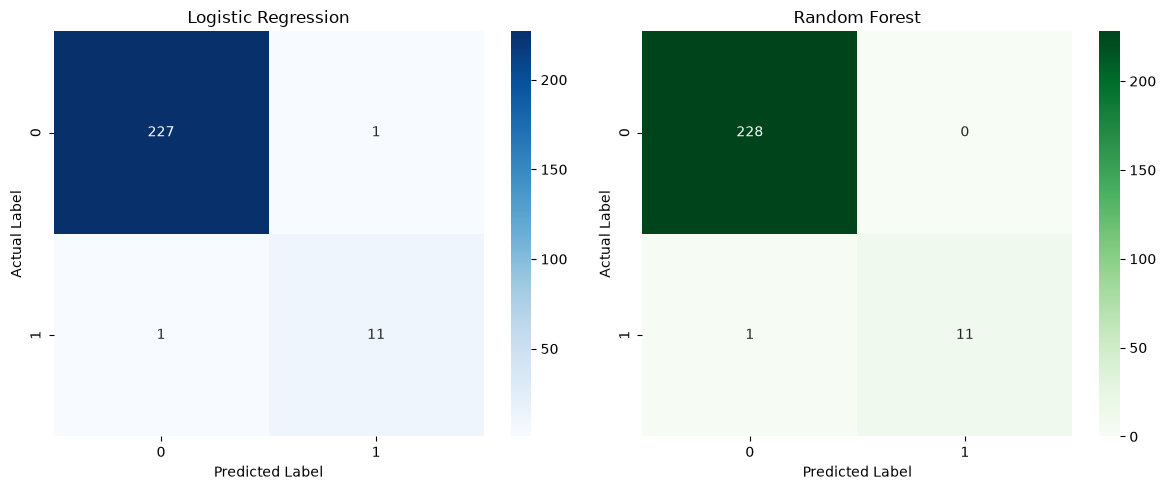

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression confusion matrix
log_cm = confusion_matrix(y_test, log_pred)

sns.heatmap(
    log_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

# Random Forest confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

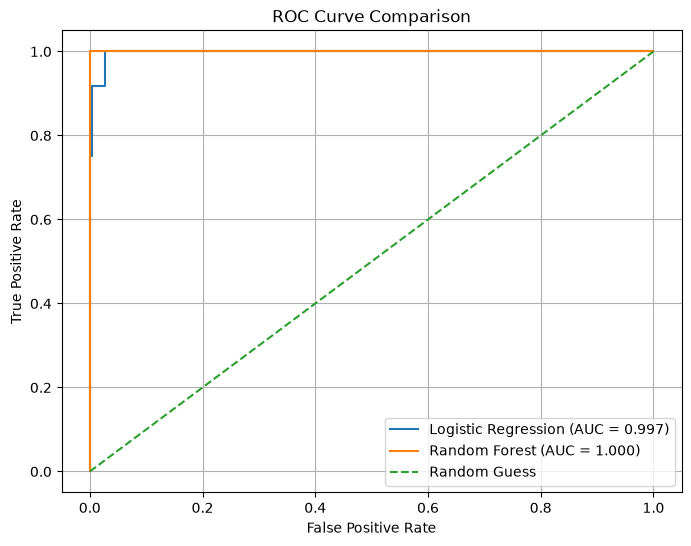

In [33]:
from sklearn.metrics import roc_curve, auc

# Probability predictions
log_prob = logistic_pipeline.predict_proba(X_test)[:, 1]
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# ROC curve values
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# AUC values
log_auc = auc(log_fpr, log_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [34]:
# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance from Random Forest
importances = rf_pipeline.named_steps["classifier"].feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 important features
feature_importance_df.head(15)

,Feature,Importance
3,num__TotalPrice,0.441803
1,num__UnitPrice,0.233682
0,num__Quantity,0.162188
2,num__ItemsInCart,0.057882
27,cat__ReferralSource_Google,0.011694
6,cat__Product_Laptop,0.010508
25,cat__ReferralSource_Email,0.007775
5,cat__Product_Desk,0.007351
26,cat__ReferralSource_Facebook,0.006995
19,cat__OrderStatus_Returned,0.006441


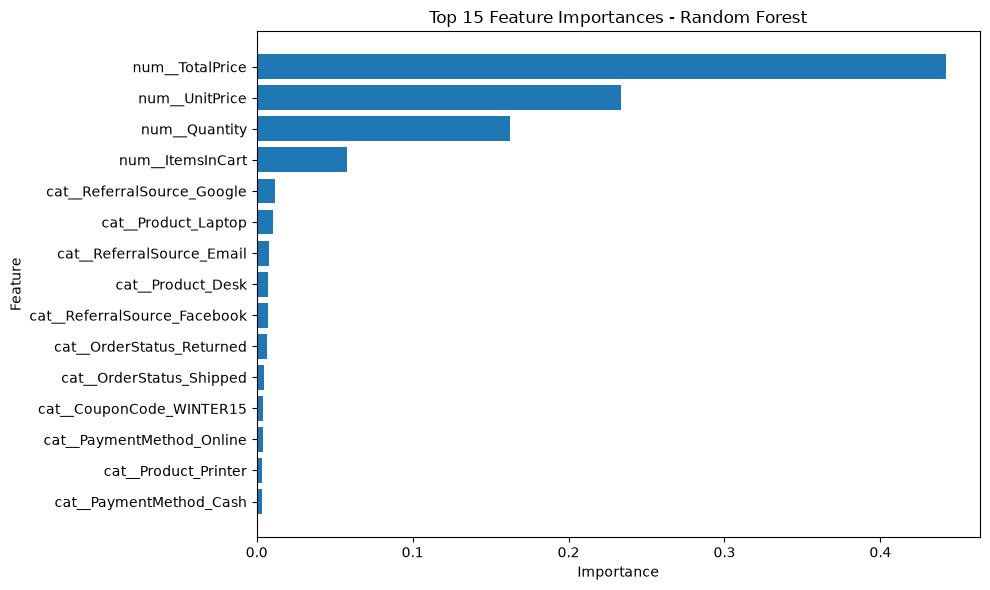

In [35]:
plt.figure(figsize=(10, 6))

top_features = feature_importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

# Project Conclusion

This project developed a fraud detection pipeline for e-commerce order data.

The dataset was cleaned and prepared by handling missing values, extracting date-related features, and encoding categorical variables. Since the original dataset did not contain a fraud label, a synthetic `IsFraud` target was created using selected transaction-related conditions.

Two machine learning models were trained and evaluated:

- Logistic Regression
- Random Forest

The models were evaluated using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, and ROC curve.

Random Forest performed better than Logistic Regression. It achieved:

- Accuracy: 99.58%
- Precision: 100%
- Recall: 91.67%
- F1-score: 95.65%
- ROC-AUC: 1.00

Therefore, Random Forest was selected as the final model for this fraud detection pipeline.

The feature importance analysis helped identify which transaction features contributed most to the model's predictions.

## Limitations

The fraud labels used in this project were synthetically generated because the original dataset did not contain a real fraud indicator. Therefore, the results demonstrate the machine learning workflow but should not be considered a real-world fraud detection performance evaluation.

## Future Improvements

- Use a real-world dataset with verified fraud labels.
- Apply advanced fraud detection algorithms.
- Perform hyperparameter tuning.
- Handle class imbalance using additional techniques.
- Deploy the model as a web application or API.